In [6]:
import numpy as np
from collections import namedtuple
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [7]:

# Create a named tuple containing the model parameters.
# Numerical values are assigned to these parameters later.
params = namedtuple(
    "params",
    [
        "C",
        "g_Na",
        "g_K",
        "g_K1",
        "E_Na",
        "E_K",
        "stim_amplitude",
        "stim_start",
        "stim_duration",
        "stim_period",
    ],
)

In [54]:

def working_myocardium_model(t, state, model_parameters):
    """
    Working myocardium model driven by a periodic external stimulus.

    Parameters
    ----------
    t : scalar
        Time point at which to evaluate dV/dt and dj/dt.

    state : tuple with 2 elements
        Current values of the membrane potential, V, and the
        potassium-channel gating variable, j.

    model_parameters : collections.namedtuple
        Model parameters stored as attributes of model_parameters.

    Returns
    -------
    tuple with 2 elements
        Values of dV/dt and dj/dt.
    """

    # Model parameters
    C = model_parameters.C

    g_Na = model_parameters.g_Na
    g_K = model_parameters.g_K
    g_K1 = model_parameters.g_K1

    E_Na = model_parameters.E_Na
    E_K = model_parameters.E_K

    stim_amplitude = model_parameters.stim_amplitude
    stim_start = model_parameters.stim_start
    stim_duration = model_parameters.stim_duration
    stim_period = model_parameters.stim_period

    # State variables
    V, j = state

    # Voltage-dependent steady-state and rate functions
    alpha_m_na = 1.0 / (1.0 + np.exp(-(V + 40.0) / 5.0))
    alpha_j = 1.0 / ( 40.0 * (1.0 + np.exp(-(V + 35.0) / 10.0)) )
    beta_j = 1.0 / ( 40.0 * (1.0 + np.exp((V + 35.0) / 10.0)) )
    x1_inf = 1.0 / ( 1.0 + np.exp((V + 75.0) / 8.0) )

    # Periodic pacing stimulus
    time_in_cycle = t % stim_period
    I_stim = stim_amplitude if (stim_start <= time_in_cycle < stim_start + stim_duration) else 0
    
    # Ionic currents
    I_Na = g_Na * alpha_m_na**3 * (V - E_Na)
    I_K = g_K * j * (V - E_K)
    I_K1 = g_K1 * x1_inf * (V - E_K)

    # Differential equations
    dVdt = -(I_Na + I_K + I_K1 + I_stim) / C
    djdt = alpha_j * (1.0 - j) - beta_j * j

    return (dVdt, djdt)

In [55]:
model_parameters = params(
    C=1.0,
    g_Na=15,
    g_K=5,
    g_K1=1.2,
    E_Na=50,
    E_K=-85,
    stim_amplitude=-30,
    stim_start=0.0,
    stim_duration=10.0,
    stim_period=100.0,
)

In [68]:
initial_state = (-80.0, 0.1)
time_span = (0, 600)
time_points = np.linspace(time_span[0], time_span[1], 10_001)

solution = solve_ivp(
    fun=working_myocardium_model,
    t_span=time_span,
    y0=initial_state,
    t_eval=time_points,
    args=(model_parameters,),
    method="BDF", max_step=0.2
)

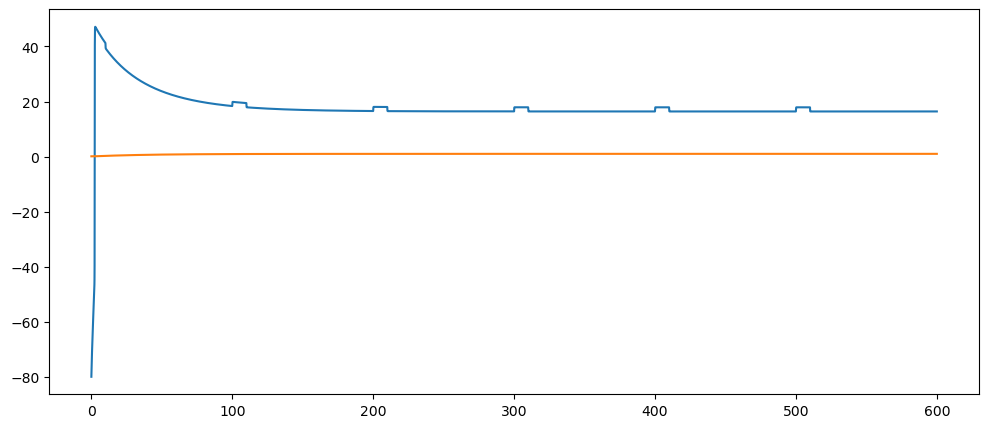

In [70]:
f, ax = plt.subplots(figsize=(12,5))

ax.plot(solution.t, solution.y[0, :])
ax.plot(solution.t, solution.y[1, :])